## Phase 0 — Environment Setup: Installing & Importing Libraries

### What Is This Cell Doing?
Before any analysis can happen, we need to load all the tools
(libraries) that Python will use throughout this notebook.
Think of this like unpacking and laying out every instrument
before starting surgery — you want everything ready before you
make the first cut.

---

### Libraries We Are Loading & Why

| Library | What It Does in This Project |
|---|---|
| `pandas` | Loads our Excel file, cleans data, filters rows/columns |
| `numpy` | Powers fast math operations behind the scenes |
| `matplotlib` | The base engine that draws every chart we create |
| `seaborn` | Draws beautiful statistical charts with minimal code |
| `sklearn` | Gives us our ML models, train/test split, and evaluation metrics |
| `xgboost` | A powerful boosting model — often wins competitions |
| `imbalanced-learn` | Fixes our class imbalance problem using SMOTE |

---

### What Is Class Imbalance?
Our dataset has **5,174 customers who did NOT churn** vs only
**1,869 who DID churn**. That's roughly a 73/27 split.

If we train a model on this as-is, it could cheat — it learns to
just predict "No Churn" for everyone and still be 73% accurate.
That's useless for business. **SMOTE** (Synthetic Minority
Oversampling Technique) fixes this by generating synthetic
examples of the minority class (churners) so the model learns both
equally well.

---

### Display Settings — Why We Configure Them
- `display.max_columns = None` → Never hide columns with "..."
- `float_format = '{:.2f}'` → Show decimals cleanly (e.g. 29.85 not 29.849999)
- `sns.set_theme(style='whitegrid')` → Every chart gets a clean,
  professional look automatically
- `figure.figsize = (10, 5)` → Charts default to a wide, readable
  size without manually resizing each one

---

### How To Know It Worked
After running, you should see:
> All libraries loaded successfully!
> Pandas version: 2.x.x
> NumPy version: 1.x.x


In [2]:
# Install and Import All Required Libraries

# --- Safe Installation Method for Windows ---
import sys
import subprocess

packages = [
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'xgboost',
    'imbalanced-learn',
    'openpyxl'
]

for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '--quiet'])

print("All packages installed!")

# --- Core Data Libraries ---
import pandas as pd
import numpy as np

# --- Visualization Libraries ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine Learning ---
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# --- Display Settings ---
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

print("All libraries loaded successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

All packages installed!
All libraries loaded successfully!
Pandas version: 2.2.3
NumPy version: 1.26.4


# Phase 1 - Loading the Dataset



## What Are We Doing?

Our data is sitting in an Excel file on your computer.
This cell is simply the act of **picking it up and
bringing it into Python**.

One line does all the heavy lifting:
```python
df = pd.read_excel('your_file.xlsx')
```

That's it. Pandas opens the file, reads every row and
column, and stores the whole thing in a variable we
are calling **df** — short for DataFrame.



## Why Do We Call It df?

It's just a convention — like how mathematicians use
x for unknowns. Every data scientist uses `df` as the
default name for their main dataset. You'll see it
everywhere in the industry.



## One Thing To Get Right

Your Excel file must be in the **same folder** as your
notebook. If it's somewhere else, you'll get a
FileNotFoundError.

> Tip: Keep your dataset and notebook in the same
> project folder. Always.



## What Success Looks Like

> Dataset loaded! Shape: (7043, 21)

7,043 rows = 7,043 customers
21 columns = 21 things we know about each customer

In [3]:
# Load the Dataset

# pd.read_excel() opens the Excel file and converts it
# into a pandas DataFrame — our main working object.

df = pd.read_excel(r"C:\Users\USER\Desktop\10Alytics\Customer Churn Dataset.xlsx")

print(f"Dataset loaded! Shape: {df.shape}")
print(f"   > {df.shape[0]} customers (rows)")
print(f"   > {df.shape[1]} features  (columns)")

Dataset loaded! Shape: (7043, 21)
   > 7043 customers (rows)
   > 21 features  (columns)


# First Look at the Data

We just loaded the data — now let's **peek inside it**.

`.head()` shows us the first 5 rows. We're not analysing
yet, just asking: *"What are we working with?"*

**Things to notice:**
- Most columns are Yes/No or categories
- `tenure`, `MonthlyCharges`, `TotalCharges` are numbers
- `customerID` is just an ID — useless for prediction
- `Churn` is the last column — that's our **target** 🎯

In [4]:
# Preview the First 5 Rows
# .head() shows the first 5 rows by default

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Inspecting the Dataset Structure

Now we look under the hood using `.info()`

This gives us a **full summary** of the dataset in one shot:
- Column names
- Data types
- Non-null counts (helps spot missing values)
- Memory usage

**Why it matters:**
Spotting wrong data types and missing values early saves
us from errors later during cleaning and modelling.

In [9]:
# Dataset Structure
# .info() gives a full structural summary of the DataFrame

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Phase 2 - Cleaned & encoded data 

## Fixing Data Types

From `.info()` we spotted two issues to fix immediately:

1. `SeniorCitizen` is `0/1` but it's really a Yes/No
   category — we convert it to "Yes"/"No"

2. `TotalCharges` has **11 missing values** — We'll look at it
indepth and come up with a solution.

In [10]:
# Fix 1: Convert SeniorCitizen from 0/1 to Yes/No
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Verify 
print(f"SeniorCitizen unique values: {df['SeniorCitizen'].unique()}")

SeniorCitizen unique values: ['No' 'Yes']


## Checking Missing Values

After inspecting the dataset structure, the next step is to identify **missing values** in the dataset.

Missing data can affect both **analysis and predictive modeling**, so it is important to detect them early.

In this step, we calculate the number of missing values for each column using the `.isnull()` function.

This helps us determine which variables require **data cleaning or imputation** before proceeding with further analysis.

In [11]:
# Checking for Missing Values
# Count missing values in each column

df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

## Investigating Missing Values in TotalCharges

We previously identified that the **TotalCharges column contains 11 missing values**.

Before deciding how to handle them, it is important to **inspect these records** to understand why the values are missing.

In many telecom churn datasets, missing `TotalCharges` values occur when:

- A customer has **tenure = 0**
- The customer has **just joined the service**
- The customer **has not yet accumulated any total charges**

In this step, we filter the dataset to display only the rows where **TotalCharges is missing**.

In [12]:
# Investigate Missing Values in TotalCharges

# Show rows where TotalCharges is missing
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,No,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


## Handling Missing Values

After investigating the missing values in the `TotalCharges` column, we observed that all affected customers have a **tenure of 0 months**.

This indicates that these customers are **newly registered and have not yet accumulated any charges**, which explains why the `TotalCharges` field is missing.

Instead of removing these rows, we replace the missing values with **0**, since this accurately reflects the customer's billing history.

Handling missing data carefully ensures that we **preserve valuable information** while maintaining dataset integrity.

In [13]:
# Handling Missing Values
# Replace missing values in TotalCharges with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Verify that no missing values remain
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Checking Unique Values in Every Column

Before we visualise or model anything, we need to know
**exactly what values live inside each column.**

This helps us spot:
- Columns with only Yes/No → simple binary categories
- Columns with 3+ categories → need different encoding
- Columns like `customerID` → unique per row, useless
  for prediction, must be dropped
- Sneaky values like `"No internet service"` which
  technically means **No** but is stored differently

💡 Notice that `MultipleLines`, `OnlineSecurity`,
`OnlineBackup`, `DeviceProtection`, `TechSupport`,
`StreamingTV` and `StreamingMovies` all have a third
value: **"No internet service"** — these customers
simply don't have internet, so they can't have these
add-ons. We'll treat this as "No" during encoding.

In [15]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in cat_cols:
    print(f"{col:20s} → {df[col].unique().tolist()}")
    print()

customerID           → ['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU', '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU', '9763-GRSKD', '7469-LKBCI', '8091-TTVAX', '0280-XJGEX', '5129-JLPIS', '3655-SNQYZ', '8191-XWSZG', '9959-WOFKT', '4190-MFLUW', '4183-MYFRB', '8779-QRDMV', '1680-VDCWW', '1066-JKSGK', '3638-WEABW', '6322-HRPFA', '6865-JZNKO', '6467-CHFZW', '8665-UTDHZ', '5248-YGIJN', '8773-HHUOZ', '3841-NFECX', '4929-XIHVW', '6827-IEAUQ', '7310-EGVHZ', '3413-BMNZE', '6234-RAAPL', '6047-YHPVI', '6572-ADKRS', '5380-WJKOV', '8168-UQWWF', '8865-TNMNX', '9489-DEDVP', '9867-JCZSP', '4671-VJLCL', '4080-IIARD', '3714-NTNFO', '5948-UJZLF', '7760-OYPDY', '7639-LIAYI', '2954-PIBKO', '8012-SOUDQ', '9420-LOJKX', '6575-SUVOI', '7495-OOKFY', '4667-QONEA', '1658-BYGOY', '8769-KKTPH', '5067-XJQFU', '3957-SQXML', '5954-BDFSG', '0434-CSFON', '1215-FIGMP', '0526-SXDJP', '0557-ASKVU', '5698-BQJOH', '5122-CYFXA', '8627-ZYGSZ', '3410-YOQBQ', '3170-NMYVV', '7410-OIED

# Unique Values Per Column

Now we look inside each column to see exactly what
values exist. This is essential before encoding or
modelling.

**Key observations from the output:**

- `customerID` → unique per row, carries zero
  predictive value — we will drop it
- Binary columns (Yes/No) → 11 columns, easy to encode
- `MultipleLines`, `OnlineSecurity`, `OnlineBackup`,
  `DeviceProtection`, `TechSupport`, `StreamingTV`,
  `StreamingMovies` → all have a 3rd value:
  **"No internet service"** — this simply means the
  customer has no internet, so they can't have these
  add-ons. We will treat this the same as "No"
- `Contract` → 3 types: Month-to-month, One year,
  Two year — this will be very important for churn
- `PaymentMethod` → 4 types including automatic vs
  manual payment methods
- `Churn` → clean binary: Yes / No 

  Knowing your unique values prevents encoding errors
   and helps you make smarter feature decisions.

# Drop Unnecessary Columns & Encode Categories

Machine learning models only understand **numbers**.
All our text columns need to be converted.

We have two types to handle:

| Type | Columns | Method |
|---|---|---|
| **Binary** (Yes/No) | gender, Partner, Dependents, PhoneService, PaperlessBilling, SeniorCitizen | Map to 1/0 |
| **"No internet service"** columns | OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, MultipleLines | Treat as "No" first, then map to 1/0 |
| **Multi-category** | InternetService, Contract, PaymentMethod | One-Hot Encoding |
| **Target** | Churn | Map Yes→1, No→0 |

**Why drop customerID?**
It's just a unique identifier — like a receipt number.
It has zero relationship with churn behaviour.
Keeping it would confuse the model.

**What is One-Hot Encoding?**
For columns with 3+ categories, we can't just use
1, 2, 3 — that implies a ranking that doesn't exist.
Instead we create a new column for each category
with a 1 or 0. Example:

| Contract | Contract_Month-to-month | Contract_One year | Contract_Two year |
|---|---|---|---|
| Month-to-month | 1 | 0 | 0 |
| Two year | 0 | 0 | 1 |

In [16]:
# Drop customerID & Encode All Categorical Columns


# Step 1: Drop customerID — it's just an identifier
df = df.drop(columns=['customerID'])

# Step 2: Columns where "No internet service" = "No"
# These customers simply have no internet, not a different category
no_internet_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines'
]
for col in no_internet_cols:
    df[col] = df[col].replace({'No internet service': 'No',
                               'No phone service': 'No'})

# Step 3: Binary columns → map Yes=1, No=0
binary_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'PaperlessBilling',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines'
]
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for col in binary_cols:
    df[col] = df[col].map(binary_map)

# Step 4: One-hot encode multi-category columns
df = pd.get_dummies(df, columns=['InternetService',
                                  'Contract',
                                  'PaymentMethod'],
                    drop_first=False)

# Step 5: Encode target variable Churn
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Verify
print(f"Encoding complete! New shape: {df.shape}")
print(f"\nChurn value counts:\n{df['Churn'].value_counts()}")
print(f"\nSample of new columns: {df.columns.tolist()}")

Encoding complete! New shape: (7043, 27)

Churn value counts:
Churn
0    5174
1    1869
Name: count, dtype: int64

Sample of new columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [ ]:
# Check dataset to review
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,29.85,0,True,False,False,True,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1889.50,0,True,False,False,False,True,False,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,108.15,1,True,False,False,True,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,1840.75,0,True,False,False,False,True,False,True,False,False,False
4,0,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,151.65,1,False,True,False,True,False,False,False,False,True,False


# Summary Statistics

Now that everything is numeric, we use `.describe()`
to get a statistical summary of every column.

**What each statistic tells us:**

| Statistic | Meaning |
|---|---|
| `count` | How many non-null values exist |
| `mean` | The average value |
| `std` | Standard deviation — how spread out values are |
| `min / max` | The smallest and largest values |
| `25% / 50% / 75%` | Percentiles — where most data sits |

**What to watch for in our dataset:**

- `tenure` → ranges 0–72 months. Mean around 32
  tells us customers are fairly spread across ages
- `MonthlyCharges` → mean ~$65, max $118.75
- `TotalCharges` → very wide range (0 to $8,684)
  because it depends on both tenure and monthly charges
- `Churn` → mean of ~0.27 confirms our 27% churn rate
- Binary columns → mean tells you the proportion.
  e.g. `SeniorCitizen` mean of ~0.16 means only
  16% of customers are seniors

In [18]:
# Summary Statistics

# Now that all columns are numeric, .describe() gives
# us a full statistical picture of the entire dataset

df.describe().T  # .T transposes so columns become rows
                 # making it much easier to read

,count,mean,std,min,25%,50%,75%,max
gender,7043.00,0.50,0.50,0.00,0.00,1.00,1.00,1.00
SeniorCitizen,7043.00,0.16,0.37,0.00,0.00,0.00,0.00,1.00
Partner,7043.00,0.48,0.50,0.00,0.00,0.00,1.00,1.00
Dependents,7043.00,0.30,0.46,0.00,0.00,0.00,1.00,1.00
tenure,7043.00,32.37,24.56,0.00,9.00,29.00,55.00,72.00
PhoneService,7043.00,0.90,0.30,0.00,1.00,1.00,1.00,1.00
MultipleLines,7043.00,0.42,0.49,0.00,0.00,0.00,1.00,1.00
OnlineSecurity,7043.00,0.29,0.45,0.00,0.00,0.00,1.00,1.00
OnlineBackup,7043.00,0.34,0.48,0.00,0.00,0.00,1.00,1.00
DeviceProtection,7043.00,0.34,0.48,0.00,0.00,0.00,1.00,1.00


# Churn Distribution (Target Variable)

Before any analysis, we must understand our target.

**What we already know:**
- 5,174 customers did NOT churn → 73.5%
- 1,869 customers DID churn → 26.5%

This is called **class imbalance** — one group is
significantly larger than the other.

**Why does this matter?**
A lazy model could predict "No Churn" for every single
customer and still be 73.5% accurate. That's useless
for a business trying to identify who will leave.

This is why we will use **SMOTE** later in modelling
to balance the classes before training.

**What this chart shows:**
A simple count of churned vs retained customers
so we can visually confirm the imbalance.

# Phase 3 - Exploratory Data Analysis (EDA)

---

## What is EDA?

EDA is simply the process of **getting to know your
data** before making any decisions or building models.

Think of it like a doctor examining a patient before
prescribing medicine. You don't just guess — you
run tests, look at results, and find patterns first.

---

## What Are We Looking For?

We explore the data in 3 stages:

| Stage | What We Do | Why |
|---|---|---|
| **Univariate** | Look at one column at a time | Understand each variable individually |
| **Bivariate** | Compare two columns together | See how each feature relates to Churn |
| **Multivariate** | Look at many columns together | Find deeper patterns and correlations |

---

## Our EDA Questions

By the end of this phase we want to answer:

- Who is churning? (age, gender, dependents)
- What services do churners use?
- How long do churners stay before leaving?
- Does contract type affect churn?
- Does how much they pay affect churn?

---

## Rule of EDA

> Never jump straight to modelling.
> Data always has a story — EDA is how you read it.

# Univariate Analysis

---

## What is Univariate Analysis?

**Uni** means one. So univariate analysis simply
means looking at **one column at a time.**

We are not comparing anything yet — we are just
asking:
> *"What does this column look like on its own?"*

Think of it like meeting someone for the first time.
Before you compare them to others, you first just
want to understand who they are individually.

---

## What We Will Look At

| Cell | Column | Question We Are Asking |
|---|---|---|
| Cell 9 | `Churn` | How many customers actually churned? |
| Cell 10 | `tenure` | How long have customers been with us? |
| Cell 11 | `MonthlyCharges` | How much do customers pay monthly? |
| Cell 12 | `TotalCharges` | How much have customers paid in total? |

---

## What To Look For

In each chart ask yourself:

- Where is the **peak**? (where most values are)
- Is the data **skewed** to one side?
- Are there any **unusual spikes**?
- What does the **average** tell us?

---

## Important Note

Univariate tells us the **shape** of each column
but NOT the **relationship** between columns.

For example — we might find many new customers.
But are those new customers the ones churning?
Univariate **cannot** answer that.

That is what Bivariate Analysis answers — but
first, let us understand each column individually.

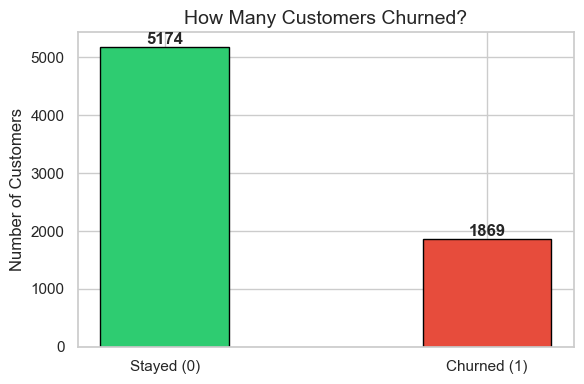

Stayed  : 5,174 (73.5%)
Churned : 1,869 (26.5%)


In [ ]:
# Churn Distribution

# How many customers churned vs stayed?

churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(['Stayed (0)', 'Churned (1)'],
        churn_counts.values,
        color=['#2ecc71', '#e74c3c'],
        edgecolor='black', width=0.4)

# Add the numbers on top of each bar
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.title('How Many Customers Churned?', fontsize=14)
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print(f"Stayed  : {churn_counts[0]:,} ({churn_counts[0]/len(df)*100:.1f}%)")
print(f"Churned : {churn_counts[1]:,} ({churn_counts[1]/len(df)*100:.1f}%)")

# How Long Have Customers Been With Us?

Our first numeric column to explore is `tenure`
— the number of months a customer has been with
the telecom company.

**Why start here?**
Because one of our EDA objectives is:
> *"How long do churners stay before leaving?"*

A histogram shows us where most customers fall.

**What to look for:**
- Are most customers new or long-term?
- Is there a spike at the beginning? (many new customers)
- Is there a spike at the end? (many loyal customers)

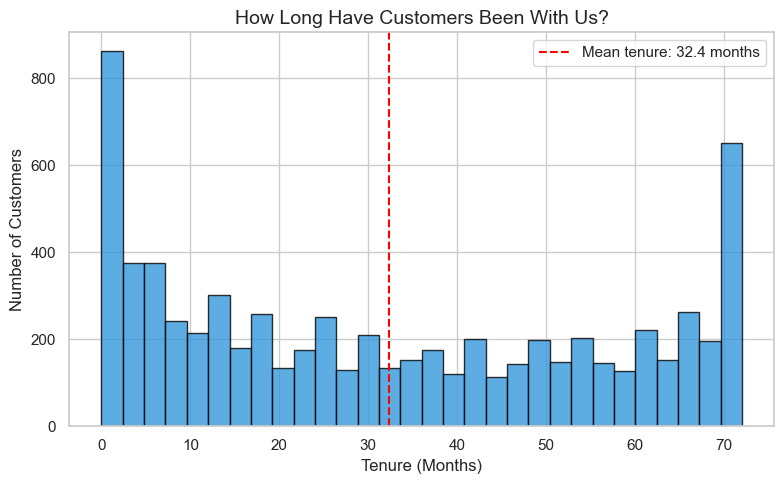

Shortest tenure : 0 months
Average tenure  : 32.4 months
Longest tenure  : 72 months


In [ ]:
# Distribution of Tenure

# How long have customers been with the company?

plt.figure(figsize=(8, 5))
plt.hist(df['tenure'], bins=30,
         color='#3498db', edgecolor='black', alpha=0.8)

plt.axvline(df['tenure'].mean(), color='red',
            linestyle='--',
            label=f"Mean tenure: {df['tenure'].mean():.1f} months")

plt.title('How Long Have Customers Been With Us?', fontsize=14)
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Shortest tenure : {df['tenure'].min()} months")
print(f"Average tenure  : {df['tenure'].mean():.1f} months")
print(f"Longest tenure  : {df['tenure'].max()} months")

# Observation — Tenure Distribution

Looking at the chart we just produced, here is what
the data is telling us:

**Two clear spikes:**
- 📈 **Month 0-1** → huge spike — many brand new customers
- 📈 **Month 70-72** → another spike — many very loyal
  long-term customers

**What this means:**
Customers tend to either **leave early** or **stay forever**.
The middle months are relatively flat — there is no
"average" customer. People make up their mind quickly.

**Average tenure is 32.4 months** — but this number
is misleading because of the two spikes pulling it
to the middle.

This raises an important question we will answer
   later in bivariate analysis:
> *"Are the churners mostly coming from that early
>    spike at month 0-1?"*

# How Much Do Customers Pay Monthly?

Next numeric column: `MonthlyCharges`

This helps us answer:
> *"Does how much they pay affect churn?"*

Are most customers on cheap plans or expensive ones?
Where does the average customer sit?

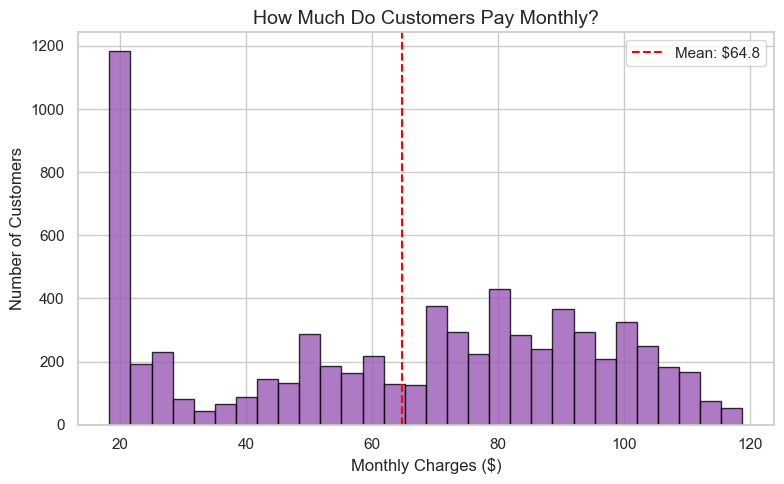

Lowest charge  : $18.25
Average charge : $64.76
Highest charge : $118.75


In [21]:
# Distribution of Monthly Charges


plt.figure(figsize=(8, 5))
plt.hist(df['MonthlyCharges'], bins=30,
         color='#9b59b6', edgecolor='black', alpha=0.8)

plt.axvline(df['MonthlyCharges'].mean(), color='red',
            linestyle='--',
            label=f"Mean: ${df['MonthlyCharges'].mean():.1f}")

plt.title('How Much Do Customers Pay Monthly?', fontsize=14)
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Lowest charge  : ${df['MonthlyCharges'].min()}")
print(f"Average charge : ${df['MonthlyCharges'].mean():.2f}")
print(f"Highest charge : ${df['MonthlyCharges'].max()}")

# Observation — Monthly Charges Distribution

**The big spike at $20:**
- Many customers are on the cheapest plan
- These are likely customers with minimal services
  (just basic phone, no internet add-ons)

**The rest of the distribution:**
- After $20 the chart spreads fairly evenly
  from $40 all the way to $120
- There is a secondary bump around $70-$80
  suggesting a popular mid-to-high tier plan

**Average is $64.8** — sitting right in the middle
of the spread, pulled up by high-paying customers.

**Two types of customers are emerging:**
| Group | Monthly Charge | Likely Profile |
|---|---|---|
| Budget customers | ~$20 | Basic plan, few add-ons |
| Premium customers | $70–$120 | Multiple services |

💡 This raises our next question:
> *"Are the high-paying customers more likely
>    to churn — or is it the budget ones?"*

We will answer this in bivariate analysis.

# Total Amount Paid by Each Customer

Last numeric column: `TotalCharges`

This is simply:
> tenure × MonthlyCharges (roughly)

So a customer who has been here 72 months paying
$100/month will have a very high TotalCharges.

This helps us understand:
> *"Do customers who have paid more overall
>    tend to stay or leave?"*

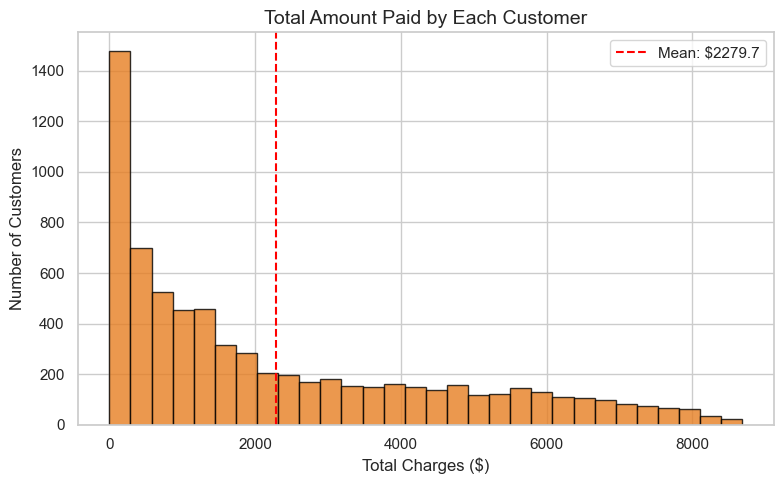

Lowest total  : $0.0
Average total : $2279.73
Highest total : $8684.8


In [22]:
# Distribution of Total Charges

plt.figure(figsize=(8, 5))
plt.hist(df['TotalCharges'], bins=30,
         color='#e67e22', edgecolor='black', alpha=0.8)

plt.axvline(df['TotalCharges'].mean(), color='red',
            linestyle='--',
            label=f"Mean: ${df['TotalCharges'].mean():.1f}")

plt.title('Total Amount Paid by Each Customer', fontsize=14)
plt.xlabel('Total Charges ($)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Lowest total  : ${df['TotalCharges'].min()}")
print(f"Average total : ${df['TotalCharges'].mean():.2f}")
print(f"Highest total : ${df['TotalCharges'].max()}")

# Observation — Total Charges Distribution

**Heavily skewed to the left** — most customers
have paid very little in total.

This makes perfect sense when we connect it back
to our tenure chart:
> Most customers are NEW (month 0-1 spike) so they
> haven't had time to accumulate high total charges yet

**What the shape tells us:**
- The tallest bar is near $0 → huge number of
  customers who just joined
- The chart has a long tail to the right → a smaller
  group of loyal customers who have paid thousands
- Mean of $2,279 is pulled to the right by those
  high-paying long-term customers

**Connecting the dots so far:**

| Column | Key Finding |
|---|---|
| `tenure` | Most customers are very new OR very old |
| `MonthlyCharges` | Big spike at $20, then spreads to $120 |
| `TotalCharges` | Most paid little — confirms many new customers |

  All three numeric columns are telling the same
   story — **this company has a lot of new customers.**

> *"Are new customers the ones churning the most?"*

We find out next in bivariate analysis! 

# Bivariate Analysis

---

## What is Bivariate Analysis?

In univariate analysis we looked at **one column
at a time**. Now we compare **two columns together**
— specifically each feature against our target: `Churn`

## Why Does This Matter?

This is where the real insights live. We stop asking
*"what does this column look like?"* and start asking:

> *"Does this column actually influence whether
>    a customer churns or not?"*

## What We Will Compare

| Question | Columns |
|---|---|
| Do churners leave early? | tenure vs Churn |
| Do high charges cause churn? | MonthlyCharges vs Churn |
| Does contract type matter? | Contract vs Churn |
| Does internet service matter? | InternetService vs Churn |
| Does gender affect churn? | gender vs Churn |
| Do seniors churn more? | SeniorCitizen vs Churn |

## What We Are Looking For
If a feature shows a **clear difference** between
churners and non-churners — it is an important
feature for our model.

# Tenure vs Churn

First bivariate question:
> *"How long do churners stay before leaving?"*

We use a **box plot** to compare tenure between
customers who churned and those who stayed.

**What is a box plot?**
- The box shows where the middle 50% of data sits
- The line in the middle is the median
- The dots outside are outliers

**What we expect to see:**
If churners have much lower tenure than non-churners
— it means customers are leaving early.

<Figure size 700x500 with 0 Axes>

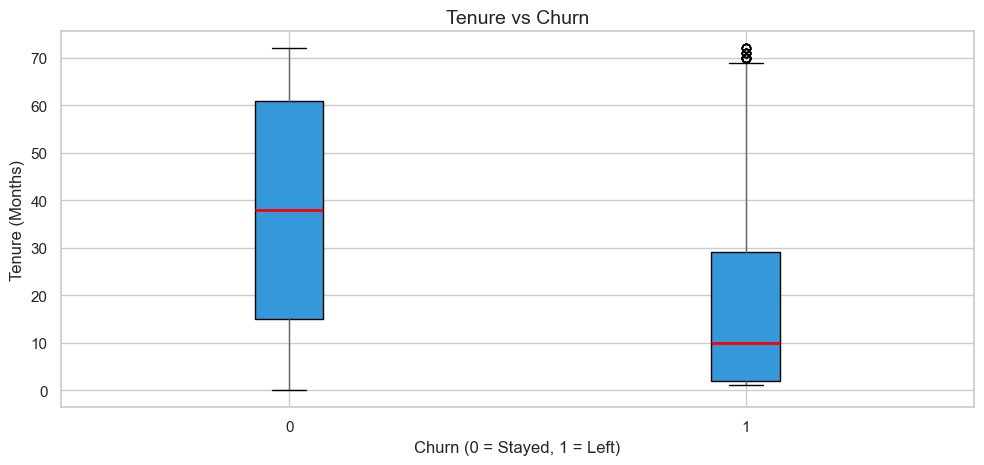

Average tenure by Churn status:
Churn
0   37.60
1   18.00
Name: tenure, dtype: float64


In [23]:
# Tenure vs Churn

plt.figure(figsize=(7, 5))
df.boxplot(column='tenure', by='Churn',
           patch_artist=True,
           boxprops=dict(facecolor='#3498db', color='black'),
           medianprops=dict(color='red', linewidth=2))

plt.title('Tenure vs Churn', fontsize=14)
plt.suptitle('')
plt.xlabel('Churn (0 = Stayed, 1 = Left)')
plt.ylabel('Tenure (Months)')
plt.tight_layout()
plt.show()

# Print average tenure for each group
print("Average tenure by Churn status:")
print(df.groupby('Churn')['tenure'].mean().round(1))

# Observation — Tenure vs Churn

This chart is one of the most telling so far.

**Customers who STAYED (0):**
- Median tenure → ~38 months
- Box spans from ~17 to ~61 months
- Wide spread — loyal customers come from all tenure lengths

**Customers who CHURNED (1):**
- Median tenure → only ~10 months
- Box spans from ~2 to ~29 months
- Very compact at the bottom — churners leave EARLY

**What this means for the business:**
> The first few months are the most dangerous period.
> If a customer survives past month 30, they are
> very likely to stay long term.

**Key Insight:**
| Group | Median Tenure |
|---|---|
| Stayed | ~38 months |
| Churned | ~10 months |

The difference is massive — **tenure is going to be
one of the most important features in our model.**

 This answers our EDA question:
> *"How long do churners stay before leaving?"*

> **Answer: Most leave within the first 10 months.**

# Monthly Charges vs Churn

Second bivariate question:
> *"Do customers who pay more churn more?"*

We already know from Cell 11 that there is a big
group paying ~$20 and others spread up to $120.

Now we ask — which group is actually leaving?

**What we expect:**
Higher paying customers may feel less value for
money and be more likely to churn. Let's find out.

<Figure size 700x500 with 0 Axes>

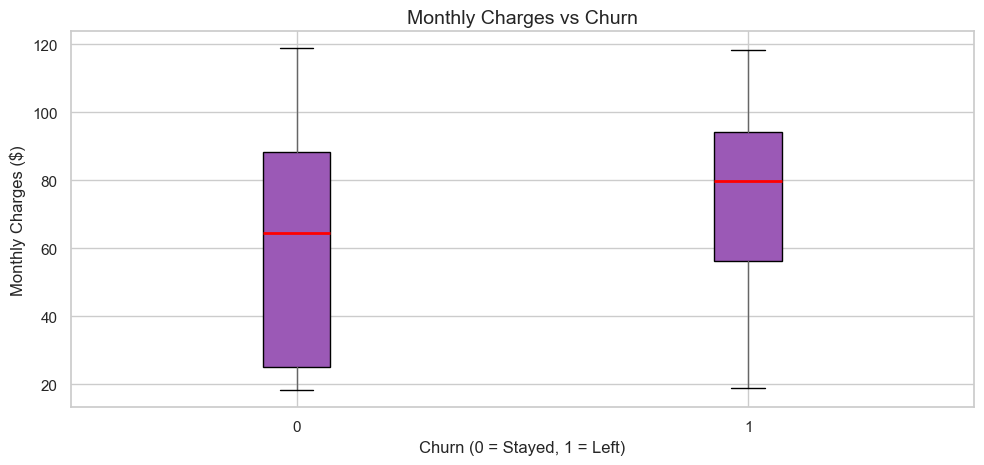

Average Monthly Charges by Churn status:
Churn
0   61.27
1   74.44
Name: MonthlyCharges, dtype: float64


In [25]:
# CELL 14: Monthly Charges vs Churn

plt.figure(figsize=(7, 5))
df.boxplot(column='MonthlyCharges', by='Churn',
           patch_artist=True,
           boxprops=dict(facecolor='#9b59b6', color='black'),
           medianprops=dict(color='red', linewidth=2))

plt.title('Monthly Charges vs Churn', fontsize=14)
plt.suptitle('')
plt.xlabel('Churn (0 = Stayed, 1 = Left)')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()

print("Average Monthly Charges by Churn status:")
print(df.groupby('Churn')['MonthlyCharges'].mean().round(2))

# Observation — Monthly Charges vs Churn

This chart confirms what we suspected.

**Customers who STAYED (0):**
- Median monthly charge → ~$65
- Box spreads widely from ~$25 to ~$89
- Many customers on cheaper plans stayed

**Customers who CHURNED (1):**
- Median monthly charge → ~$80
- Box is compact between ~$59 to ~$94
- Churners are concentrated in the higher price range

**The numbers confirm it:**
| Group | Average Monthly Charge |
|---|---|
| Stayed | $61.27 |
| Churned | $74.44 |

Churners pay **$13 more per month** on average
than customers who stayed.

**What this means for the business:**
> Higher paying customers feel less value for money
> and are more likely to leave. These are likely
> customers on expensive plans with multiple add-ons
> but still not satisfied enough to stay.

 This answers our EDA question:
> *"Does how much they pay affect churn?"*

> **Answer: Yes — higher charges = higher churn risk.**

# Contract Type vs Churn

Third bivariate question:
> *"Does the type of contract affect churn?"*

Recall we have 3 contract types:
- **Month-to-month** → no commitment, easy to leave
- **One year** → some commitment
- **Two year** → strongest commitment

**What we expect:**
Month-to-month customers have nothing locking them
in — they can leave any time. We expect them to
churn the most.

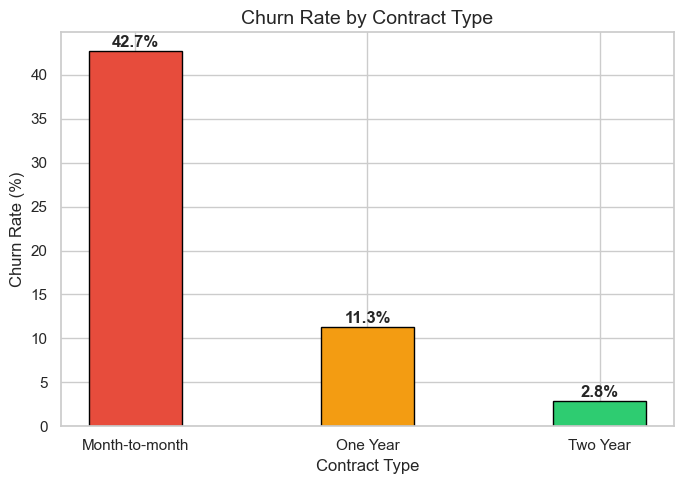

Churn Rate by Contract Type:
Contract_Type
Month-to-month   42.70
One Year         11.30
Two Year          2.80
Name: Churn, dtype: float64


In [26]:
# Contract Type vs Churn

# Calculate churn rate per contract type
contract_churn = df.groupby([
    'Contract_Month-to-month',
    'Contract_One year',
    'Contract_Two year'
])['Churn'].mean() * 100

# Simpler approach — rebuild contract column for plotting
df['Contract_Type'] = 'Month-to-month'
df.loc[df['Contract_One year'] == 1, 'Contract_Type'] = 'One Year'
df.loc[df['Contract_Two year'] == 1, 'Contract_Type'] = 'Two Year'

churn_by_contract = df.groupby('Contract_Type')['Churn'].mean() * 100

plt.figure(figsize=(7, 5))
bars = plt.bar(churn_by_contract.index,
               churn_by_contract.values,
               color=['#e74c3c', '#f39c12', '#2ecc71'],
               edgecolor='black', width=0.4)

# Add percentage labels on bars
for bar, val in zip(bars, churn_by_contract.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Churn Rate by Contract Type', fontsize=14)
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

print("Churn Rate by Contract Type:")
print(churn_by_contract.round(1))

# Observation — Contract Type vs Churn

This is the most powerful chart we have seen so far.

**The numbers speak for themselves:**
| Contract Type | Churn Rate |
|---|---|
| Month-to-month | 42.7% |
| One Year | 11.3% |
| Two Year | 2.8% |

**Month-to-month customers churn at 42.7%** —
nearly half of them leave. That is enormous.

**Two year customers churn at only 2.8%** —
almost nobody on a long contract leaves.

**The difference is 15x:**
> A month-to-month customer is **15 times more
> likely to churn** than a two year customer.

**Why does this make sense?**
- Month-to-month = zero commitment = easy to leave
- Two year = signed a contract = locked in
- One year = sits in the middle at 11.3%

**What this means for the business:**
> The single most effective retention strategy is
> to move customers from month-to-month contracts
> onto longer term contracts as early as possible.

 This answers our EDA question:
> *"Does contract type affect churn?"*

> **Answer: Absolutely — it is the strongest
> signal we have found so far.**

# Internet Service vs Churn

Fourth bivariate question:
> *"Does the type of internet service affect churn?"*

Recall we have 3 internet service types:
- **DSL** → slower, cheaper connection
- **Fiber optic** → faster, more expensive connection
- **No internet** → no internet service at all

**What we expect:**
Fiber optic customers pay more — and we already
know higher charges link to higher churn.
We expect fiber optic customers to churn the most.

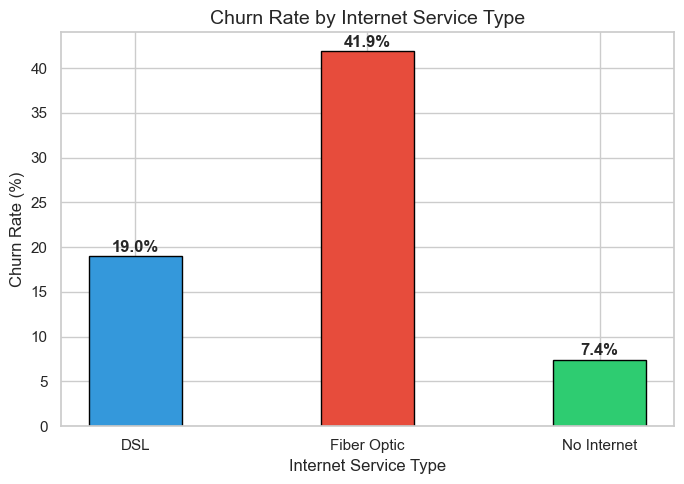

Churn Rate by Internet Service:
Internet_Type
DSL           19.00
Fiber Optic   41.90
No Internet    7.40
Name: Churn, dtype: float64


In [27]:
# Internet Service vs Churn

# Rebuild internet service column for plotting
df['Internet_Type'] = 'No Internet'
df.loc[df['InternetService_DSL'] == 1, 'Internet_Type'] = 'DSL'
df.loc[df['InternetService_Fiber optic'] == 1, 'Internet_Type'] = 'Fiber Optic'

churn_by_internet = df.groupby('Internet_Type')['Churn'].mean() * 100

plt.figure(figsize=(7, 5))
bars = plt.bar(churn_by_internet.index,
               churn_by_internet.values,
               color=['#3498db', '#e74c3c', '#2ecc71'],
               edgecolor='black', width=0.4)

for bar, val in zip(bars, churn_by_internet.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Churn Rate by Internet Service Type', fontsize=14)
plt.xlabel('Internet Service Type')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

print("Churn Rate by Internet Service:")
print(churn_by_internet.round(1))

# Observation — Internet Service vs Churn

Our prediction was exactly right.

**The numbers:**
| Internet Service | Churn Rate |
|---|---|
| Fiber Optic | 41.9% |
| DSL | 19.0% |
| No Internet | 7.4% |

**Fiber Optic customers churn at 41.9%** —
almost identical to month-to-month contracts.
This is a serious problem for the company.

**Why are Fiber Optic customers leaving?**
They are paying the most but may feel:
- The service quality doesn't justify the price
- Competitors are offering better fiber deals
- They came in on a promotional price that ended

**No Internet customers barely churn at 7.4%**
These are likely basic phone-only customers who
are satisfied with their simple, cheap service.

**Connecting to what we already know:**
> Fiber Optic customers tend to be on
> month-to-month contracts AND pay high monthly
> charges — three risk factors combining together.

| Risk Factor | Rate |
|---|---|
| Month-to-month contract | 42.7% churn |
| Fiber Optic internet | 41.9% churn |
| High monthly charges | $74.44 avg for churners |

This answers our EDA question:
> *"Does internet service type affect churn?"*

> **Answer: Yes — Fiber Optic is a major red flag.**

# Senior Citizen vs Churn

Fifth bivariate question:
> *"Do senior citizens churn more than
>    non-senior customers?"*

From our summary statistics we know only **16%**
of customers are senior citizens.

But the question is not how many there are —
it's whether they churn at a higher rate.

**What we expect:**
Senior citizens may be less tech-savvy and more
likely to be confused or dissatisfied with
complex telecom services and pricing.

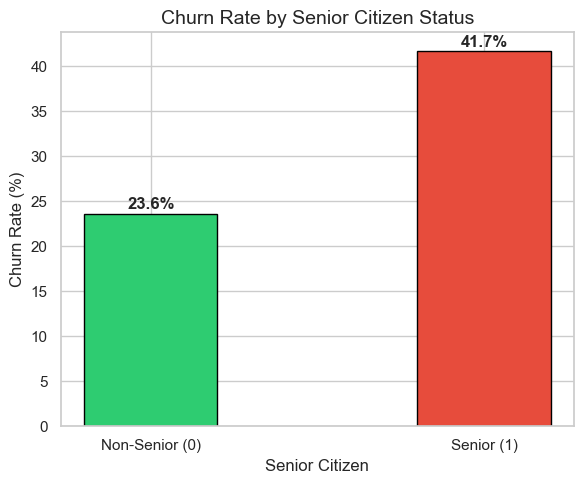

Churn Rate by Senior Citizen Status:
SeniorCitizen
0   23.60
1   41.70
Name: Churn, dtype: float64

Customer Count by Senior Citizen Status:
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


In [28]:
# CELL 17: Senior Citizen vs Churn

churn_by_senior = df.groupby('SeniorCitizen')['Churn'].mean() * 100

plt.figure(figsize=(6, 5))
bars = plt.bar(['Non-Senior (0)', 'Senior (1)'],
               churn_by_senior.values,
               color=['#2ecc71', '#e74c3c'],
               edgecolor='black', width=0.4)

for bar, val in zip(bars, churn_by_senior.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Churn Rate by Senior Citizen Status', fontsize=14)
plt.xlabel('Senior Citizen')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

print("Churn Rate by Senior Citizen Status:")
print(churn_by_senior.round(1))

print("\nCustomer Count by Senior Citizen Status:")
print(df['SeniorCitizen'].value_counts())

# Observation — Senior Citizen vs Churn

Our prediction was correct again.

**The numbers:**
| Customer Type | Churn Rate | Count |
|---|---|---|
| Non-Senior | 23.6% | 5,901 |
| Senior | 41.7% | 1,142 |

**Senior citizens churn at 41.7%** — nearly
double the rate of non-senior customers at 23.6%.

**Important context:**
Seniors are only **16% of all customers** (1,142
out of 7,043) — but their churn rate is massive.

**Why might seniors churn more?**
- May find the service too complex or confusing
- More likely to be on expensive plans they
  don't fully understand
- May be targeted by competitors with
  simpler, cheaper alternatives
- Less likely to have set up automatic payments
  which could lead to accidental cancellations

**A pattern is forming:**
Every high-risk group we find tends to share
the same profile:

| Risk Factor | Churn Rate |
|---|---|
| Month-to-month contract | 42.7% |
| Fiber Optic internet | 41.9% |
| Senior Citizen | 41.7% |

These three factors are clustering around
   the same ~42% churn rate. This suggests
   they may all be describing the **same group
   of customers.**

# Gender vs Churn

Sixth bivariate question:
> *"Does gender affect whether a customer churns?"*

We encoded gender earlier as:
- **0 = Female**
- **1 = Male**

**What we expect:**
Honestly — we don't expect much difference here.
Churn is more likely driven by service quality
and pricing than by gender.

But we check anyway because assumptions in data
science must always be verified, never guessed.

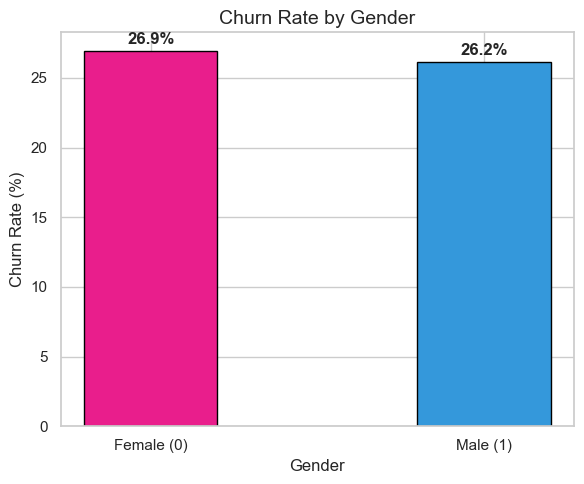

Churn Rate by Gender:
gender
0   26.90
1   26.20
Name: Churn, dtype: float64


In [29]:
# Gender vs Churn

churn_by_gender = df.groupby('gender')['Churn'].mean() * 100

plt.figure(figsize=(6, 5))
bars = plt.bar(['Female (0)', 'Male (1)'],
               churn_by_gender.values,
               color=['#e91e8c', '#3498db'],
               edgecolor='black', width=0.4)

for bar, val in zip(bars, churn_by_gender.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Churn Rate by Gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

print("Churn Rate by Gender:")
print(churn_by_gender.round(1))

# Observation — Gender vs Churn

Our prediction was spot on this time.

**The numbers:**
| Gender | Churn Rate |
|---|---|
| Female | 26.9% |
| Male | 26.2% |

**Virtually no difference at all.**
Only 0.7% separates females from males.

**What this means:**
Gender is NOT a useful predictor of churn.
Both groups leave at almost exactly the same rate.

**This is actually an important finding:**
Not every column will be useful for our model.
Gender is a good example of a feature that
looks important but contributes nothing.

> In machine learning we call this a
> **low importance feature** — it adds noise
> without adding predictive power.

**Comparing all bivariate findings so far:**
| Feature | Churn Rate Difference | Important? |
|---|---|---|
| Contract type | 42.7% vs 2.8% | Very much |
| Fiber Optic | 41.9% vs 7.4% | Very much |
| Senior Citizen | 41.7% vs 23.6% | Yes |
| Monthly Charges | $74 vs $61 avg | Yes |
| Tenure | 10 vs 38 months | Very much |
| Gender | 26.9% vs 26.2% | No |

Gender will likely rank very low in our
   model's feature importance. Let's keep
   exploring before we build the model.

# Multivariate Analysis

---

## What is Multivariate Analysis?

**Multi** means many. So multivariate analysis
looks at **multiple columns together** at the
same time.

In bivariate we asked:
> "How does THIS feature relate to Churn?"

Now we ask:
> "How do ALL features relate to each other
>   AND to Churn — all at once?"

---

## What We Did in Bivariate

| Feature | Finding |
|---|---|
| Tenure | Churners leave within 10 months |
| Monthly Charges | Churners pay $13 more on average |
| Contract Type | Month-to-month = 42.7% churn |
| Internet Service | Fiber Optic = 41.9% churn |
| Senior Citizen | Seniors churn at 41.7% |
| Gender | No difference — 26.9% vs 26.2% |

---

## What We Will Do Now

We will use a **Correlation Heatmap** to see
all relationships in one single chart.

This tells us:
- Which features are strongly linked to Churn
- Which features are linked to each other
- Which features are completely unrelated

---

## What is Correlation?

Correlation measures how closely two variables
move together. It ranges from -1 to +1:

| Value | Meaning |
|---|---|
| Close to +1 | Strong positive relationship |
| Close to -1 | Strong negative relationship |
| Close to 0 | No relationship |

# Correlation Heatmap

A heatmap shows the correlation between
every column in our dataset at once.

**How to read it:**
- **Dark red** → strong positive correlation
- **Dark blue** → strong negative correlation
- **White/light** → little or no correlation
- The diagonal is always 1.0 (a column
  perfectly correlates with itself)

**What we are looking for:**
The `Churn` row/column — which features
have the strongest correlation with it?

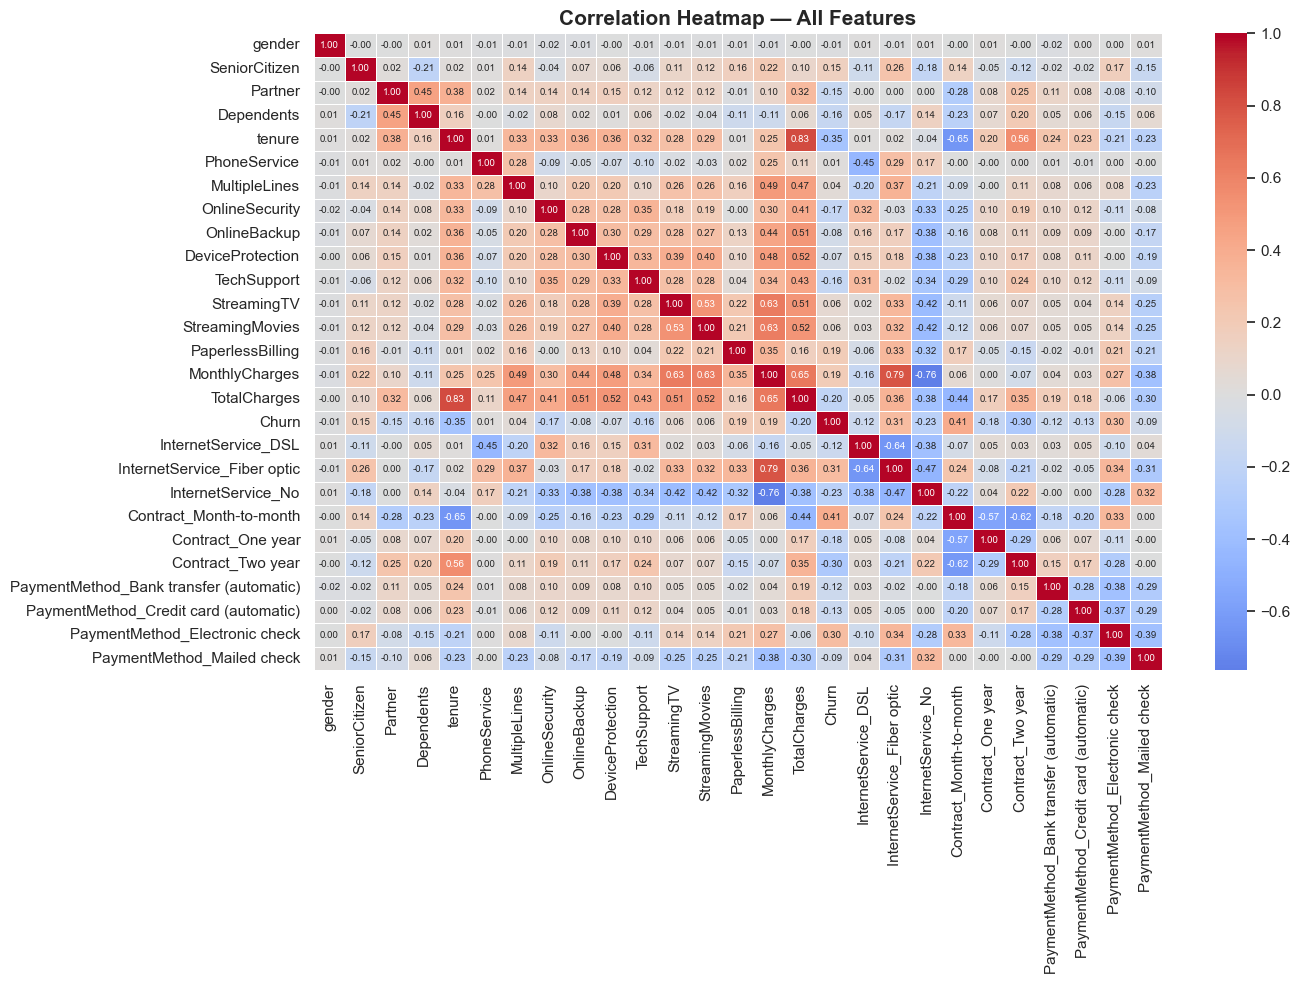

Correlation with Churn (ranked):
Churn                                      1.00
Contract_Month-to-month                    0.41
InternetService_Fiber optic                0.31
PaymentMethod_Electronic check             0.30
MonthlyCharges                             0.19
PaperlessBilling                           0.19
SeniorCitizen                              0.15
StreamingTV                                0.06
StreamingMovies                            0.06
MultipleLines                              0.04
PhoneService                               0.01
gender                                    -0.01
DeviceProtection                          -0.07
OnlineBackup                              -0.08
PaymentMethod_Mailed check                -0.09
PaymentMethod_Bank transfer (automatic)   -0.12
InternetService_DSL                       -0.12
PaymentMethod_Credit card (automatic)     -0.13
Partner                                   -0.15
Dependents                                -0.16
TechSup

In [31]:
# Correlation Heatmap

# Drop the temporary columns we created for plotting
df_corr = df.drop(columns=['Contract_Type',
                            'Internet_Type'], errors='ignore')

plt.figure(figsize=(14, 10))
corr_matrix = df_corr.corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            annot_kws={'size': 7})

plt.title('Correlation Heatmap — All Features',
          fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Print just the Churn correlations ranked
print("Correlation with Churn (ranked):")
print(corr_matrix['Churn'].sort_values(ascending=False).round(2))

# Observation — Correlation Heatmap

This single chart confirms everything we found
in bivariate analysis — and adds new insights.

---

## Features Most Positively Correlated with Churn
*(higher value = more likely to churn)*

| Feature | Correlation | Meaning |
|---|---|---|
| Contract_Month-to-month | +0.41 | Strongest churn driver |
| Fiber Optic Internet | +0.31 | High churn service |
| Electronic check payment | +0.30 | Risky payment method |
| MonthlyCharges | +0.19 | Higher bills = more churn |
| PaperlessBilling | +0.19 | Slight churn link |
| SeniorCitizen | +0.15 | Seniors churn more |

---

## Features Most Negatively Correlated with Churn
*(lower value = less likely to churn)*

| Feature | Correlation | Meaning |
|---|---|---|
| tenure | -0.35 | Longer tenure = stays |
| Contract_Two year | -0.30 | Long contract = stays |
| InternetService_No | -0.23 | No internet = stays |
| Contract_One year | -0.18 | Medium contract = safer |
| TotalCharges | -0.20 | More paid = stays |

---

## New Insight — Electronic Check!
We hadn't looked at payment method yet but
the heatmap reveals it:
> Customers paying by **electronic check**
> have a +0.30 correlation with churn —
> the 3rd strongest signal in the dataset.

---

## Gender Confirmed Useless
Gender correlation with Churn = **-0.01**
Essentially zero — exactly as we predicted.

---

## The High Risk Customer Profile
Combining everything we now know:

> A customer is most likely to churn if they:
> - Are on a **month-to-month** contract
> - Have **Fiber Optic** internet
> - Pay via **electronic check**
> - Have **low tenure** (new customer)
> - Pay **high monthly charges**
> - Are a **senior citizen**

This profile will guide our model features
   and our business recommendations.

# Phase 4 — Feature Engineering & Preparing for Modelling

---

## What is Feature Engineering?

Feature Engineering is the process of **preparing
your data** so that a machine learning model can
learn from it as effectively as possible.

Think of it like preparing ingredients before
cooking. You don't throw a whole onion into a pot
— you peel it, chop it, and measure it first.

---

## What We Need To Do

| Step | What | Why |
|---|---|---|
| 1 | Separate features from target | Model needs X and y separately |
| 2 | Split data into train and test sets | Test on unseen data |
| 3 | Scale numeric columns | Big numbers shouldn't overpower small ones |
| 4 | Fix class imbalance with SMOTE | Stop the model from cheating |

---

## Why Split Into Train and Test?

We train the model on one portion of data
and test it on a completely separate portion
it has never seen before.

> Think of it like studying for an exam with
> a textbook — then being tested on questions
> from a different paper.

We use an **80/20 split:**
- 80% of data → training the model
- 20% of data → testing the model

---

## Why Scale Numeric Columns?

Our numeric columns have very different ranges:
- `tenure` → 0 to 72
- `MonthlyCharges` → 18 to 119
- `TotalCharges` → 0 to 8,684

Without scaling, `TotalCharges` would dominate
simply because its numbers are bigger — not
because it is more important.

**StandardScaler** fixes this by converting all
values to the same scale with mean=0, std=1.

---

## Why Fix Class Imbalance?

We have 73.5% No Churn vs 26.5% Churn.
A lazy model predicts "No Churn" every time
and gets 73.5% accuracy — but catches zero
actual churners. That is useless.

**SMOTE** (Synthetic Minority Oversampling
Technique) creates synthetic examples of the
minority class (churners) until both classes
are balanced 50/50.

> We apply SMOTE ONLY on training data —
> never on test data. The test set must always
> reflect the real world.

# Separate Features from Target

Before we can train any model we need to split
our DataFrame into two separate parts:

- **X** → all the input columns (features)
  everything the model learns FROM
- **y** → the target column (Churn)
  everything the model tries to PREDICT

Think of it like a student studying:
- **X** = the study material
- **y** = the exam answers

The model studies X to learn how to predict y.

In [32]:
# Separate Features (X) and Target (y)

# Drop temporary plotting columns and target to get X
X = df.drop(columns=['Churn',
                      'Contract_Type',
                      'Internet_Type'], errors='ignore')

# Target variable
y = df['Churn']

print(f"✅ Features shape (X): {X.shape}")
print(f"✅ Target shape   (y): {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
for col in X.columns:
    print(f"   → {col}")
print(f"\nTarget distribution:")
print(y.value_counts())

✅ Features shape (X): (7043, 26)
✅ Target shape   (y): (7043,)

Feature columns (26):
   → gender
   → SeniorCitizen
   → Partner
   → Dependents
   → tenure
   → PhoneService
   → MultipleLines
   → OnlineSecurity
   → OnlineBackup
   → DeviceProtection
   → TechSupport
   → StreamingTV
   → StreamingMovies
   → PaperlessBilling
   → MonthlyCharges
   → TotalCharges
   → InternetService_DSL
   → InternetService_Fiber optic
   → InternetService_No
   → Contract_Month-to-month
   → Contract_One year
   → Contract_Two year
   → PaymentMethod_Bank transfer (automatic)
   → PaymentMethod_Credit card (automatic)
   → PaymentMethod_Electronic check
   → PaymentMethod_Mailed check

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


# Split Data into Train and Test Sets

Now we split our data into two sets:

- **Training set (80%)** → the model learns from this
- **Test set (20%)** → we use this to evaluate the model

**Why 80/20?**
It is the most common split in data science.
80% gives the model enough data to learn from
while 20% gives us enough data to test fairly.

**What is random_state=42?**
It fixes the random split so that every time
you run this cell you get the exact same split.
Without it the split would be different every
time making results impossible to reproduce.

> After this point the test set goes in a
> "vault" — we do not touch it until final
> model evaluation.

In [ ]:
# Train / Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,     # reproducible split
    stratify=y           # maintain churn ratio in both sets
)

print(f"Split complete!")
print(f"\nTraining set : {X_train.shape[0]} customers (80%)")
print(f"Test set     : {X_test.shape[0]} customers (20%)")
print(f"\nChurn rate in training set: {y_train.mean()*100:.1f}%")
print(f"Churn rate in test set    : {y_test.mean()*100:.1f}%")

✅ Split complete!

Training set : 5634 customers (80%)
Test set     : 1409 customers (20%)

Churn rate in training set: 26.5%
Churn rate in test set    : 26.5%


# Scaling Numeric Columns

Our three numeric columns have very different
ranges and need to be brought to the same scale:

| Column | Min | Max |
|---|---|---|
| `tenure` | 0 | 72 |
| `MonthlyCharges` | 18 | 119 |
| `TotalCharges` | 0 | 8,684 |

Without scaling, `TotalCharges` would dominate
the model simply because its numbers are larger
— not because it is more important.

**StandardScaler** converts each value using:
> z = (value - mean) / standard deviation

This gives every column a mean of 0 and a
standard deviation of 1 — a level playing field.

**Important rule:**
- We **fit** the scaler on training data only
- We **transform** both train and test data
- Never fit on test data — that would be cheating
  because the model would have seen test data
  before evaluation

In [34]:
# Scale Numeric Columns

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Columns to scale
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Fit ONLY on training data, transform both
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("✅ Scaling complete!")
print(f"\nTraining set — scaled column stats:")
print(X_train[numeric_cols].describe().round(2))

✅ Scaling complete!

Training set — scaled column stats:
       tenure  MonthlyCharges  TotalCharges
count 5634.00         5634.00       5634.00
mean    -0.00           -0.00          0.00
std      1.00            1.00          1.00
min     -1.32           -1.54         -1.01
25%     -0.96           -0.97         -0.83
50%     -0.14            0.18         -0.40
75%      0.92            0.83          0.67
max      1.61            1.79          2.80


# Fix Class Imbalance with SMOTE

We have a problem with our training data:
- **73.5%** are No Churn (majority class)
- **26.5%** are Churn (minority class)

A model trained on this imbalanced data will
learn to just predict "No Churn" every time
because that is the safe, easy answer.

**SMOTE fixes this by:**
Creating brand new *synthetic* customers that
look like churners — based on existing churners
in the training data.

It does NOT just copy existing churners.
It creates realistic new ones by looking at
the characteristics of real churners and
generating similar examples.

**The result:**
A perfectly balanced 50/50 training set that
forces the model to learn BOTH classes equally.

> Remember — SMOTE is applied ONLY on the
> training set. The test set stays untouched
> so it reflects real world conditions.

In [35]:
# Apply SMOTE to Balance Training Data

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("✅ SMOTE applied!")
print(f"\nBefore SMOTE:")
print(f"  No Churn : {sum(y_train == 0):,}")
print(f"  Churn    : {sum(y_train == 1):,}")
print(f"\nAfter SMOTE:")
print(f"  No Churn : {sum(y_train_sm == 0):,}")
print(f"  Churn    : {sum(y_train_sm == 1):,}")
print(f"\nNew training set size: {X_train_sm.shape[0]:,} customers")

✅ SMOTE applied!

Before SMOTE:
  No Churn : 4,139
  Churn    : 1,495

After SMOTE:
  No Churn : 4,139
  Churn    : 4,139

New training set size: 8,278 customers


# Phase 5 — Machine Learning Modelling

---

## What Are We Doing Here?

We have cleaned the data, explored it, and
prepared it. Now we finally build the models
that will **predict which customers will churn.**

---

## What is a Machine Learning Model?

A model is simply a mathematical function that
learns patterns from data and uses those patterns
to make predictions on new unseen data.

Think of it like teaching a child:
- You show them many examples (training)
- They learn the patterns
- You test them on new examples (testing)
- You measure how well they did (evaluation)

---

## The 3 Models We Will Build

| Model | Difficulty | How It Works |
|---|---|---|
| **Logistic Regression** | Beginner | Draws a line to separate churners from non-churners |
| **Random Forest** | Intermediate | Builds many decision trees and combines their votes |
| **XGBoost** | Advanced | Builds trees one after another, each learning from the previous one's mistakes |

---

## Why 3 Models?

Different models have different strengths.
By building all three we can:
- Compare their performance
- Pick the best one
- Understand why one works better than others

---

## How We Evaluate Each Model

After training we measure each model using:

| Metric | What It Measures |
|---|---|
| **Accuracy** | Overall % of correct predictions |
| **Precision** | Of all predicted churners, how many actually churned? |
| **Recall** | Of all actual churners, how many did we catch? |
| **F1 Score** | Balance between precision and recall |
| **ROC-AUC** | Overall ability to separate churners from non-churners |

---

## Which Metric Matters Most Here?

For churn prediction **Recall is most important.**

> It is better to wrongly flag a loyal customer
> as a churner (and offer them a discount) than
> to miss a real churner and lose them forever.

Missing a churner costs the company far more
than a unnecessary retention offer.

In [36]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Build and train the model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_sm, y_train_sm)

# Make predictions on test set
lr_preds = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

# Evaluate
print("=" * 50)
print("   MODEL 1 — LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(classification_report(y_test, lr_preds,
      target_names=['No Churn', 'Churn']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_proba):.4f}")

   MODEL 1 — LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

    No Churn       0.89      0.77      0.83      1035
       Churn       0.54      0.72      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409

ROC-AUC Score: 0.8356


# Observation — Logistic Regression Results

**Overall Performance:**
| Metric | Score |
|---|---|
| Accuracy | 76% |
| ROC-AUC | 0.8356 |

---

## Breaking Down the Results

**For No Churn customers:**
| Metric | Score | Meaning |
|---|---|---|
| Precision | 89% | When it predicts "Stay" it is right 89% of the time |
| Recall | 77% | It correctly identifies 77% of all loyal customers |

**For Churn customers:**
| Metric | Score | Meaning |
|---|---|---|
| Precision | 54% | When it predicts "Churn" it is right 54% of the time |
| Recall | 72% | It correctly catches 72% of all actual churners |

---

## Is This Good?

**The good:**
- ROC-AUC of 0.84 is actually quite solid
- Recall of 72% means we catch 72 out of every
  100 churners — not bad for a simple model
- Fast and interpretable

**The not so good:**
- Precision of 54% on Churn means almost half
  of our churn predictions are wrong
- We are missing 28% of actual churners

---

## This is Our Baseline

Every model we build next must beat these numbers:
> Target: Recall > 72%, ROC-AUC > 0.84

Let's see if Random Forest can do better.

# Model 2: Random Forest

**What is a Random Forest?**
A Random Forest builds **many decision trees**
and combines all their predictions together.

Think of it like asking 100 doctors for their
opinion instead of just one. The majority vote
wins — and the combined wisdom is almost always
better than any single doctor alone.

**What is a Decision Tree?**
A tree of yes/no questions:
- "Is tenure < 10 months?" → Yes → likely churner
- "Is contract month-to-month?" → Yes → even more likely
- And so on until a final prediction is made

**Why is Random Forest better than one tree?**
A single tree tends to **overfit** — it memorises
the training data perfectly but performs poorly
on new data. Many trees together are more robust.

**What we expect:**
Random Forest should outperform Logistic
Regression because it can capture more complex
non-linear patterns in the data.

In [37]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

# Build and train the model
rf_model = RandomForestClassifier(n_estimators=100,
                                   random_state=42)
rf_model.fit(X_train_sm, y_train_sm)

# Make predictions on test set
rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

# Evaluate
print("=" * 50)
print("   MODEL 2 — RANDOM FOREST RESULTS")
print("=" * 50)
print(classification_report(y_test, rf_preds,
      target_names=['No Churn', 'Churn']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_proba):.4f}")

   MODEL 2 — RANDOM FOREST RESULTS
              precision    recall  f1-score   support

    No Churn       0.86      0.82      0.84      1035
       Churn       0.56      0.64      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.77      1409

ROC-AUC Score: 0.8228


# Observation — Random Forest Results

**Overall Performance:**
| Metric | Score |
|---|---|
| Accuracy | 77% |
| ROC-AUC | 0.8228 |

---

## Comparing Random Forest vs Logistic Regression

| Metric | Logistic Regression | Random Forest | Winner |
|---|---|---|---|
| Accuracy | 76% | 77% | RF |
| ROC-AUC | 0.8356 | 0.8228 | LR |
| Churn Recall | 72% | 64% | LR |
| Churn Precision | 54% | 56% | RF |
| No Churn Recall | 77% | 82% | RF |

---

## Surprising Result!

Random Forest did NOT beat Logistic Regression
on the metrics that matter most to us.

**What happened?**
- Random Forest is better at identifying loyal
  customers (No Churn recall 82% vs 77%)
- But it is worse at catching actual churners
  (Churn recall 64% vs 72%)

Remember our most important metric is **Recall
on Churn** — catching as many churners as possible.
On that measure Logistic Regression still leads.

**ROC-AUC also dropped:**
0.8228 vs 0.8356 — Logistic Regression wins here too.

---

## Logistic Regression Still Leads

| Model | Churn Recall | ROC-AUC |
|---|---|---|
| Logistic Regression | **72%** | **0.8356** |
| Random Forest | 64% | 0.8228 |

This is a great lesson:
> More complex does not always mean better.
> A simple model can sometimes outperform
> a complex one — especially on smaller datasets.

Let's see if XGBoost can finally beat our baseline.

# Model 3: XGBoost

**What is XGBoost?**
XGBoost stands for **Extreme Gradient Boosting.**
It is one of the most powerful and widely used
machine learning algorithms in the world.

**How is it different from Random Forest?**

| Random Forest | XGBoost |
|---|---|
| Builds trees independently | Builds trees sequentially |
| Trees vote equally | Each tree fixes previous mistakes |
| All trees at once | One tree at a time |

**The key idea — Boosting:**
Imagine a student who takes a test, reviews
every wrong answer, then takes the test again
focusing only on what they got wrong.
XGBoost does exactly this — each new tree
focuses on the mistakes of the previous tree.

**Why is XGBoost so popular?**
- Wins most Kaggle competitions
- Handles imbalanced data well
- Very fast and efficient
- Works well on tabular data like ours

**What we expect:**
XGBoost should be our best performing model
and finally beat our Logistic Regression baseline.

In [38]:
# XGBoost

from xgboost import XGBClassifier

# Build and train the model
xgb_model = XGBClassifier(n_estimators=100,
                           random_state=42,
                           eval_metric='logloss',
                           verbosity=0)
xgb_model.fit(X_train_sm, y_train_sm)

# Make predictions on test set
xgb_preds = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate
print("=" * 50)
print("   MODEL 3 — XGBOOST RESULTS")
print("=" * 50)
print(classification_report(y_test, xgb_preds,
      target_names=['No Churn', 'Churn']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, xgb_proba):.4f}")

   MODEL 3 — XGBOOST RESULTS
              precision    recall  f1-score   support

    No Churn       0.87      0.80      0.84      1035
       Churn       0.55      0.68      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409

ROC-AUC Score: 0.8076


# Observation — XGBoost Results

**Overall Performance:**
| Metric | Score |
|---|---|
| Accuracy | 77% |
| ROC-AUC | 0.8076 |

---

## The Full Model Comparison

| Metric | Logistic Regression | Random Forest | XGBoost |
|---|---|---|---|
| Accuracy | 76% | 77% | 77% |
| ROC-AUC | **0.8356** | 0.8228 | 0.8076 |
| Churn Recall | **72%** | 64% | 68% |
| Churn Precision | 54% | 56% | **55%** |
| No Churn Recall | 77% | **82%** | 80% |

---

## Surprising Overall Finding!

XGBoost — the most complex model — came last
on our two most important metrics.

**Churn Recall ranking:**
1. Logistic Regression → 72%
2. XGBoost → 68%
3. Random Forest → 64%

**ROC-AUC ranking:**
1. Logistic Regression → 0.8356
2. Random Forest → 0.8228
3. XGBoost → 0.8076

---

## Why Did This Happen?

A few possible reasons:
- Our dataset is relatively small (7,043 rows)
  Complex models need more data to shine
- Logistic Regression works very well when
  relationships between features and target
  are fairly linear — which ours appear to be
- We used default hyperparameters for all models
  Tuning XGBoost could improve its performance

---

## Winner: Logistic Regression

> Sometimes the simplest tool is the best tool.
> A model does not need to be complex to be good.
> Logistic Regression wins on both Recall and
> ROC-AUC — the metrics that matter most here.

# Phase 6 — Model Evaluation & Visualisation

---

## What Are We Doing Here?

We have built and compared 3 models. Now we go
deeper into evaluating our best model —
**Logistic Regression** — using visual tools
that make the results easier to understand.

Numbers alone can be hard to interpret.
Charts make performance immediately obvious.

---

## What We Will Visualise

| Visualisation | What It Shows |
|---|---|
| Confusion Matrix | Exactly where the model is right and wrong |
| ROC Curve | How well the model separates churners from non-churners |
| Feature Importance | Which features drive churn predictions the most |
| Model Comparison | Side by side comparison of all 3 models |

---

## Key Terms to Know

**Confusion Matrix — 4 outcomes:**

| | Predicted No Churn | Predicted Churn |
|---|---|---|
| **Actual No Churn** | ✅ True Negative | ❌ False Positive |
| **Actual Churn** | ❌ False Negative | ✅ True Positive |

- **True Positive** → correctly caught a churner 
- **True Negative** → correctly identified a loyal customer 
- **False Positive** → wrongly flagged a loyal customer as churner
- **False Negative** → missed a real churner, most costly!

**ROC Curve:**
Plots True Positive Rate vs False Positive Rate
at different thresholds. The closer the curve
hugs the top left corner the better the model.

**AUC (Area Under Curve):**
- 1.0 = perfect model
- 0.5 = random guessing
- Our best = 0.8356 → very good!

# Confusion Matrix

The confusion matrix shows us exactly where
our model is getting things right and wrong.

**The 4 boxes explained simply:**

| Box | Name | Meaning |
|---|---|---|
| Top Left | True Negative | Correctly said "will stay" |
| Top Right | False Positive | Wrongly said "will churn" |
| Bottom Left | False Negative | Missed a real churner  |
| Bottom Right | True Positive | Correctly caught a churner  |

**What we want:**
- Bottom Left (False Negatives) as small as possible
  These are churners we completely missed
- Bottom Right (True Positives) as large as possible
  These are churners we successfully caught

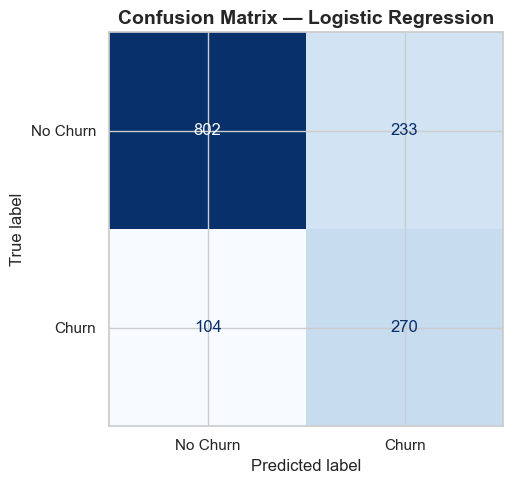

 True Negatives  (correctly said Stay)  : 802
 False Positives (wrongly said Churn)   : 233
  False Negatives (missed churners)      : 104
 True Positives  (correctly caught)     : 270

Of 374 actual churners we caught 270 (72.2%)


In [39]:
# Confusion Matrix — Logistic Regression

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, lr_preds)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Churn', 'Churn'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)

ax.set_title('Confusion Matrix — Logistic Regression',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Break down the numbers
tn, fp, fn, tp = cm.ravel()
print(f" True Negatives  (correctly said Stay)  : {tn}")
print(f" False Positives (wrongly said Churn)   : {fp}")
print(f"  False Negatives (missed churners)      : {fn}")
print(f" True Positives  (correctly caught)     : {tp}")
print(f"\nOf {tp+fn} actual churners we caught {tp} ({tp/(tp+fn)*100:.1f}%)")

# ROC Curve

Shows how well the model separates churners
from non-churners at different thresholds.

The closer the curve hugs the **top left corner**
the better. A diagonal line = random guessing.

**AUC closer to 1.0 = better model.**

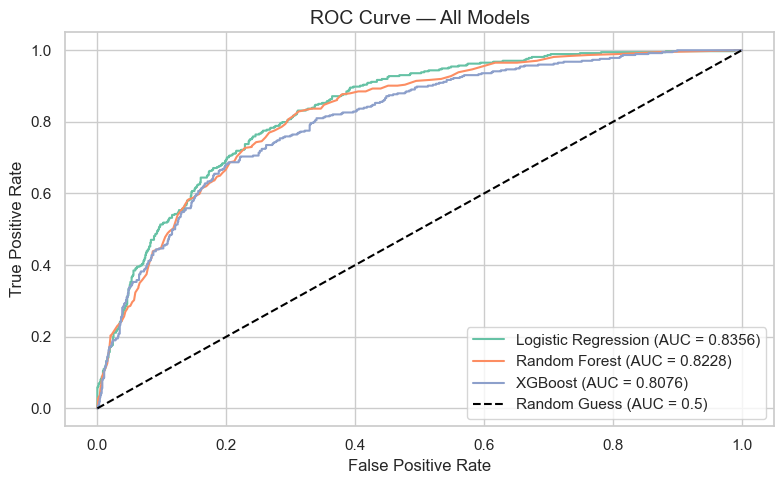

AUC Scores:
  Logistic Regression : 0.8356 
  Random Forest       : 0.8228 
  XGBoost             : 0.8076 


In [40]:
# ROC Curve — All 3 Models

from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 5))

# Plot all 3 models
for name, proba in [('Logistic Regression', lr_proba),
                    ('Random Forest', rf_proba),
                    ('XGBoost', xgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

# Random guess baseline
plt.plot([0,1], [0,1], 'k--', label='Random Guess (AUC = 0.5)')

plt.title('ROC Curve — All Models', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

# AUC Scores
print("AUC Scores:")
print(f"  Logistic Regression : {roc_auc_score(y_test, lr_proba):.4f} ")
print(f"  Random Forest       : {roc_auc_score(y_test, rf_proba):.4f} ")
print(f"  XGBoost             : {roc_auc_score(y_test, xgb_proba):.4f} ")

# Feature Importance

Which features drive churn predictions the most?

This tells us exactly what the model learned
and confirms whether it matches our EDA findings.

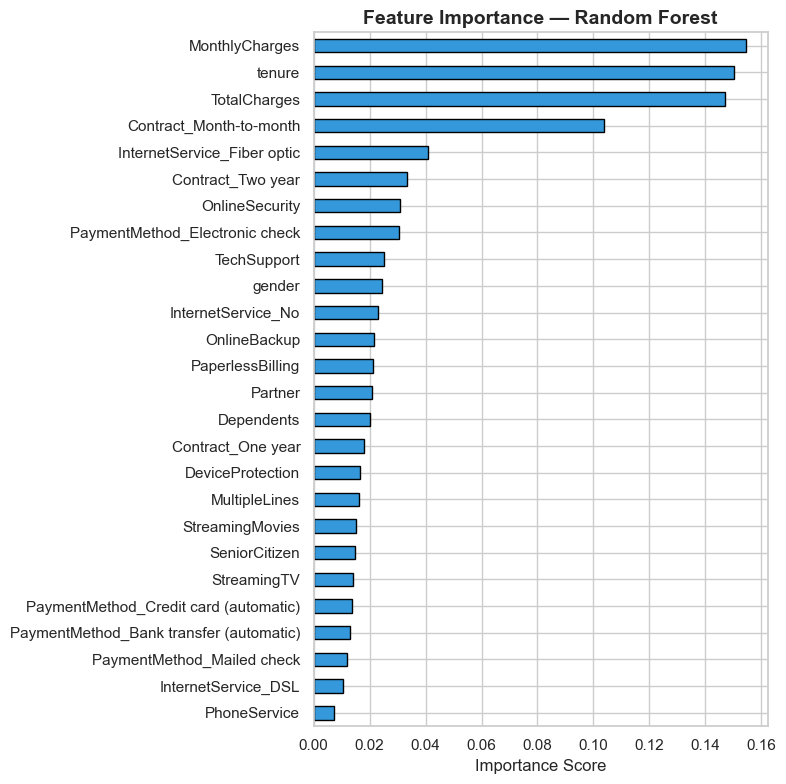

Top 5 Most Important Features:
MonthlyCharges                0.15
tenure                        0.15
TotalCharges                  0.15
Contract_Month-to-month       0.10
InternetService_Fiber optic   0.04
dtype: float64


In [41]:
# Feature Importance — Random Forest

# We use Random Forest for feature importance
# because it gives a clean built-in importance score

importances = pd.Series(rf_model.feature_importances_,
                        index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 8))
importances.plot(kind='barh', color='#3498db',
                 edgecolor='black')

plt.title('Feature Importance — Random Forest',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 5 Most Important Features:")
print(importances.sort_values(ascending=False).head())

# Final Model Comparison

One chart summarising all 3 models side by side
across every metric — so we can clearly crown
our winner.

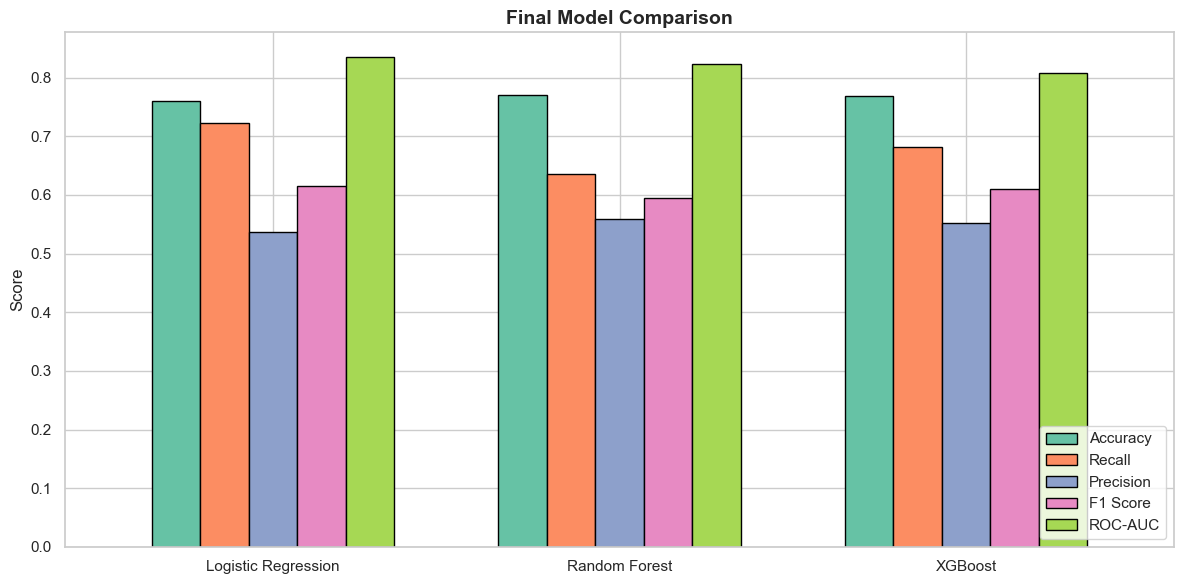


 Final Scores Table:
                     Accuracy  Recall  Precision  F1 Score  ROC-AUC
Logistic Regression      0.76    0.72       0.54      0.62     0.84
Random Forest            0.77    0.64       0.56      0.59     0.82
XGBoost                  0.77    0.68       0.55      0.61     0.81


In [42]:
# Final Model Comparison

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

# Collect all scores
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
metrics = {
    'Accuracy'  : [accuracy_score(y_test, lr_preds),
                   accuracy_score(y_test, rf_preds),
                   accuracy_score(y_test, xgb_preds)],
    'Recall'    : [recall_score(y_test, lr_preds),
                   recall_score(y_test, rf_preds),
                   recall_score(y_test, xgb_preds)],
    'Precision' : [precision_score(y_test, lr_preds),
                   precision_score(y_test, rf_preds),
                   precision_score(y_test, xgb_preds)],
    'F1 Score'  : [f1_score(y_test, lr_preds),
                   f1_score(y_test, rf_preds),
                   f1_score(y_test, xgb_preds)],
    'ROC-AUC'   : [roc_auc_score(y_test, lr_proba),
                   roc_auc_score(y_test, rf_proba),
                   roc_auc_score(y_test, xgb_proba)]
}

results_df = pd.DataFrame(metrics, index=models)

# Plot
results_df.plot(kind='bar', figsize=(12, 6),
                edgecolor='black', width=0.7)
plt.title('Final Model Comparison', fontsize=14,
          fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("\n Final Scores Table:")
print(results_df.round(4))

# Business Insights & Recommendations

---

## What Are We Doing Here?

We have cleaned data, explored it, built models
and evaluated them. But none of that matters
unless we can translate our findings into
**actions the business can actually take.**

This is the most important phase for stakeholders
— they don't care about ROC-AUC scores.
They care about **how to stop losing customers.**

---

## What The Data Told Us

| Finding | Evidence |
|---|---|
| New customers leave early | Median churn tenure = 10 months |
| Month-to-month is dangerous | 42.7% churn rate |
| Fiber Optic has a problem | 41.9% churn rate |
| High charges drive churn | Churners pay $13 more/month |
| Seniors are vulnerable | 41.7% churn rate |
| Electronic check is risky | 3rd strongest churn signal |
| Gender doesn't matter | 26.9% vs 26.2% — negligible |

---

## The High Risk Customer Profile

> A customer most likely to churn is:
> - **New** (tenure < 10 months)
> - On a **month-to-month** contract
> - Using **Fiber Optic** internet
> - Paying via **electronic check**
> - A **senior citizen**
> - Paying **high monthly charges**

---

## Our Recommendations

| # | Action | Target Group | Expected Impact |
|---|---|---|---|
| 1 | Offer discounts to move customers to yearly contracts | Month-to-month customers | Reduce 42.7% → closer to 11.3% |
| 2 | Investigate Fiber Optic service quality | Fiber Optic customers | Reduce 41.9% churn |
| 3 | Create an early intervention programme | Customers in first 10 months | Catch churners before they decide |
| 4 | Incentivise automatic payment setup | Electronic check users | Remove friction in payment |
| 5 | Dedicated senior citizen support | Senior customers | Reduce 41.7% churn |
| 6 | Review pricing for high charge customers |

# Phase 8 — Deploying with Streamlit

---

## What is Streamlit?

Streamlit turns your Python model into a
**live interactive web app** — no web development
experience needed.

Anyone can open it in a browser, enter a
customer's details, and instantly see:
- Whether that customer is likely to churn
- The probability score
- What risk factors are driving it

---

## What We Need To Do First

Before building the app we need to **save our
trained model** so Streamlit can load and use it
without retraining every time.

We use a library called `joblib` to save it.

## Steps
1. Save the trained model → `model.pkl`
2. Save the scaler → `scaler.pkl`
3. Build the Streamlit app → `app.py`
4. Run it locally

In [ ]:
# Save Model & Scaler

import joblib

# Save the winning model
joblib.dump(lr_model, 'churn_model.pkl')

# Save the scaler
joblib.dump(scaler, 'churn_scaler.pkl')

# Save the feature column names
joblib.dump(list(X.columns), 'feature_columns.pkl')

print("Model saved    → churn_model.pkl")
print("Scaler saved   → churn_scaler.pkl")
print("Features saved → feature_columns.pkl")

✅ Model saved    → churn_model.pkl
✅ Scaler saved   → churn_scaler.pkl
✅ Features saved → feature_columns.pkl
